<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/10_Experimental_Data_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10 — Experimental Data Template

This notebook shows how to use `probunmix` with real experimental data.

The key principle is simple:

> Synthetic and experimental data must become the same `UnmixingData` object. Everything downstream is identical.

For the current package, concentration and mixture fraction are treated as the same quantity.

Minimal experimental inputs are:

- `E`: spectral coordinate, shape `(M,)`;
- `Y`: measured spectra, shape `(N, M)`;
- `W_mean`: measured concentrations/fractions, shape `(N, K)`;
- `W_sigma`: concentration uncertainty, shape `(N, K)`;
- `sigma_y`: spectral measurement uncertainty, scalar or broadcastable to `(N, M)`.

After constructing the data object, attach the spectral knowledge needed for Level 0, 1, or 2.

In [ ]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## 1. Replace this demonstration cell with your experimental loader

A real workflow might use `np.load`, `np.loadtxt`, `pandas.read_csv`, or another instrument-specific reader.

The demonstration below creates arrays synthetically, then deliberately discards the hidden truth and reconstructs an experimental-style `UnmixingData` object.

In [ ]:
# DEMONSTRATION ONLY.
# Replace this block with loading of your own E, Y, W_mean, W_sigma,
# sigma_y, and spectral prior information.

source = pu.generate_example(
    n_locations=30,
    n_channels=100,
    n_library=60,
    concentration_uncertainty=[0.02, 0.04, 0.06, 0.08],
    spectral_uncertainty=[0.5, 1.0, 1.5, 2.0],
    seed=2026,
)

E = source.E.copy()
Y = source.Y.copy()
W_mean = source.W_mean.copy()
W_sigma = source.W_sigma.copy()
sigma_y = np.asarray(source.sigma_y).copy()

# Examples of spectral knowledge that might come from independent
# references, physical models, simulations, or calibration data.
S_reference = source.S_fixed.copy()
theta_mean = source.theta_mean.copy()
theta_sigma = source.theta_sigma.copy()
S_library = source.S_library.copy()

## 2. Construct the experimental data object

Only measured quantities are passed here. Synthetic truth is not attached.

In [ ]:
data = pu.from_arrays(
    E=E,
    Y=Y,
    W_mean=W_mean,
    W_sigma=W_sigma,
    sigma_y=sigma_y,
)

print("Synthetic truth attached:",
      data.W_true is not None or data.S_true is not None)

pu.validate_data(data)
pu.print_data_summary(data)

Synthetic truth attached: False
Probabilistic Unmixing Dataset

Dimensions
----------
Locations:          30
Spectral channels:  100
Components:         4

Spectral data
-------------
Spectral axis:      0 to 12
Measured intensity: -0.01492 to 0.8108

Composition / mixture fractions
-------------------------------
Row-sum range:      1.000000 to 1.000000
Mean row sum:       1.000000

Available spectral knowledge
----------------------------
Level 0 fixed spectra:      NO
Level 1 parametric prior:   NO
Level 2 functional library: NO

Evaluation information
----------------------
Synthetic truth:            NO


## 3. Attach the spectral knowledge you actually have

You do **not** need to attach all three levels in a real analysis. Attach only the representation justified by your experiment.

This demonstration attaches all three so that the common interface can be shown.

In [ ]:
data.set_level0(S_reference)

data.set_level1(
    model="two_gaussian",
    theta_mean=theta_mean,
    theta_sigma=theta_sigma,
)

data.set_level2(S_library)

pu.print_data_summary(data)

Probabilistic Unmixing Dataset

Dimensions
----------
Locations:          30
Spectral channels:  100
Components:         4

Spectral data
-------------
Spectral axis:      0 to 12
Measured intensity: -0.01492 to 0.8108

Composition / mixture fractions
-------------------------------
Row-sum range:      1.000000 to 1.000000
Mean row sum:       1.000000

Available spectral knowledge
----------------------------
Level 0 fixed spectra:      YES
Level 1 parametric prior:   YES
Level 2 functional library: YES

Evaluation information
----------------------
Synthetic truth:            NO


## 4. Run the desired level

Here we run all three only for demonstration. In a real experiment, choose the level that corresponds to your actual prior knowledge.

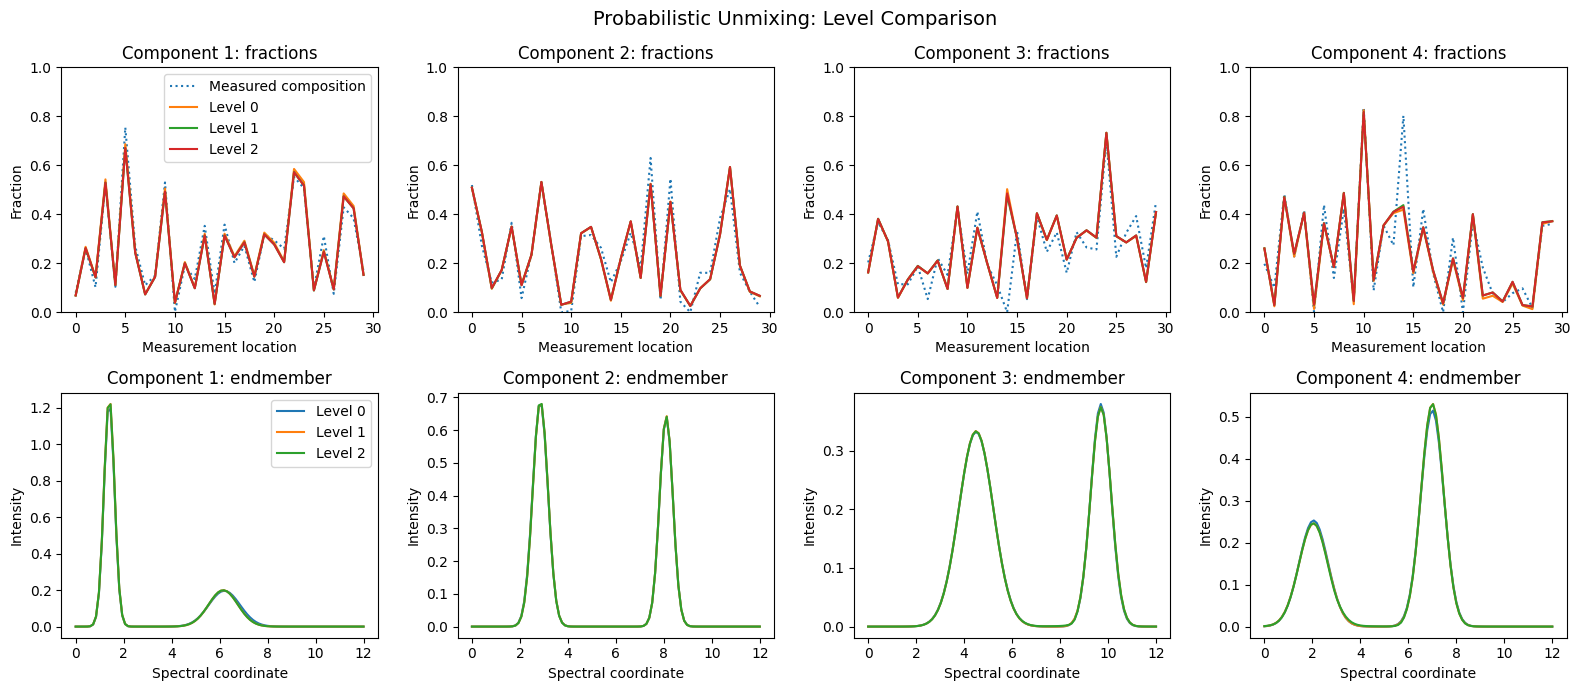

In [ ]:
result0 = pu.fit(data, level=0, n_draws=400, seed=100)

result1 = pu.fit(
    data, level=1, n_draws=400, seed=101, max_nfev=200
)

result2 = pu.fit(
    data, level=2, n_draws=400, seed=102, max_nfev=200
)

pu.plot_level_comparison(
    data,
    result0,
    result1,
    result2,
);

## 5. What changes for real data?

Truth-based quantities such as `concentration_rmse` and `spectral_rmse` are absent because the truth is unknown.

The experimentally meaningful outputs are instead:

- posterior concentration means and uncertainties;
- posterior endmember means and uncertainties;
- reconstructed spectra;
- residuals;
- convergence/optimization diagnostics;
- sensitivity to the assumed spectral prior.

Systematic residual structure is especially important because it can indicate missing components, background terms, spectral shifts, nonlinear mixing, or failure of the assumption that composition equals mixture fraction.

Level 2 metrics:
{'reconstruction_rmse': 0.020352095258291777, 'mean_concentration_sd': 0.014868798051710689, 'mean_spectral_sd': 0.0015832287112103722, 'n_functional_parameters': 43, 'n_total_parameters': 133, 'optimizer_cost': 1500.515052899192, 'optimizer_nfev': 61}

Truth-based concentration RMSE present? False
Truth-based spectral RMSE present? False


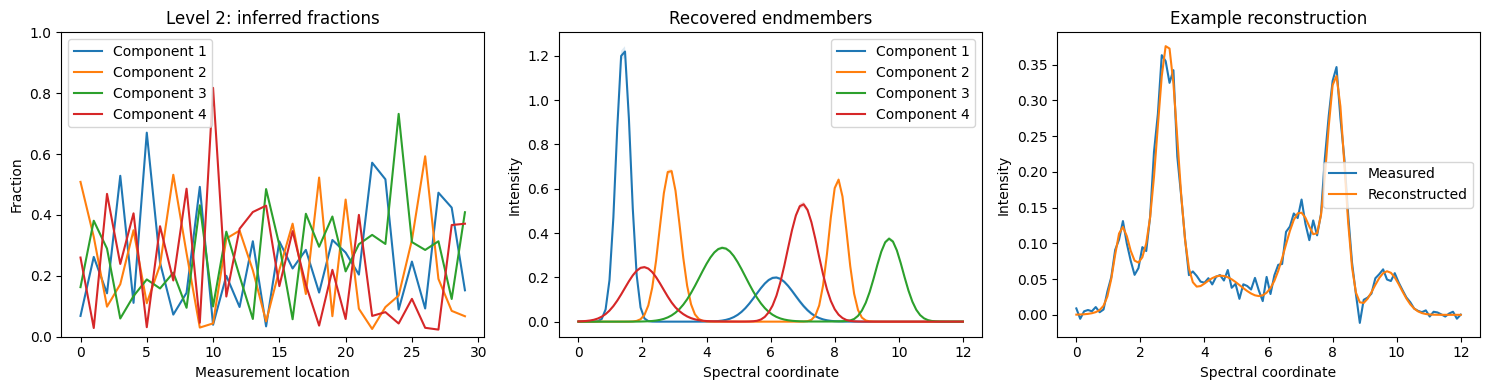

In [ ]:
print("Level 2 metrics:")
print(result2.metrics)

print()
print("Truth-based concentration RMSE present?",
      "concentration_rmse" in result2.metrics)

print("Truth-based spectral RMSE present?",
      "spectral_rmse" in result2.metrics)

pu.plot_result(data, result2);

## Loading real files: minimal pattern

Replace the demonstration arrays with your own file reads, for example:

```python
E = np.loadtxt("energy.csv", delimiter=",")
Y = np.load("spectra.npy")
W_mean = np.load("composition_mean.npy")
W_sigma = np.load("composition_sd.npy")
sigma_y = np.load("spectral_noise.npy")

data = pu.from_arrays(
    E=E,
    Y=Y,
    W_mean=W_mean,
    W_sigma=W_sigma,
    sigma_y=sigma_y,
)
```

Then attach `S_reference`, a Level 1 parameter prior, or `S_library`, and use exactly the same `pu.fit(...)` calls shown above.